# Notebook 02 — Clustering & Segmentation des Pays
**Projet :** Analyse comparative des pays
**Auteur :** Hajar Mamdouh | Formation Data Analyst - Simplon

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

# Chemin fixe vers ton projet
FINAL_DIR = r'C:\Users\Amine Mamdouh\Desktop\fil-rouge-investissement-main\data\final'
PLOTS_DIR = r'C:\Users\Amine Mamdouh\Desktop\fil-rouge-investissement-main\reports\plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Fichier existe : {os.path.exists(os.path.join(FINAL_DIR, "master_dataset.csv"))}')
print('OK')

Fichier existe : True
OK


## 1. Chargement et préparation

In [4]:
df = pd.read_csv(os.path.join(FINAL_DIR, 'master_dataset.csv'))

best_year_hap = int(df.dropna(subset=['happiness_score']).groupby('year').size().idxmax())
latest_year = best_year_hap

print(f'Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'Pays    : {df["country_code"].nunique()}')
print(f'Année utilisée : {latest_year}')
df.head()

Dataset : 1222 lignes x 21 colonnes
Pays    : 169
Année utilisée : 2019


,country_code,year,gdp_growth,inflation,population,gni_per_capita,life_expectancy,literacy_rate,country_name,region,...,gdp_per_capita,happiness_score,social_support,life_expectancy_whr,freedom,generosity,corruption,positive_affect,negative_affect,attractivity_score
0,ABW,2015,3.611480,NaN,107906.0,25430.0,NaN,NaN,Aruba,Latin America & Caribbean,...,27458.220154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523049
1,ABW,2016,1.234335,NaN,108727.0,25560.0,NaN,NaN,Aruba,Latin America & Caribbean,...,27441.550214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523035
2,ABW,2017,3.493430,NaN,108735.0,26460.0,NaN,NaN,Aruba,Latin America & Caribbean,...,28440.041688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523910
3,ABW,2018,3.212471,NaN,108908.0,27970.0,NaN,NaN,Aruba,Latin America & Caribbean,...,30082.158423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525349
4,ABW,2019,1.225112,NaN,109203.0,29320.0,NaN,NaN,Aruba,Latin America & Caribbean,...,30645.890602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525843


## 2. Méthode du coude — Trouver le k optimal

In [5]:
FEATURES = ['gdp_per_capita', 'happiness_score', 'life_expectancy',
            'freedom', 'corruption', 'social_support', 'inflation', 'gdp_growth']
features_available = [f for f in FEATURES if f in df.columns]
print(f'Features disponibles : {features_available}')

df_clust = df[df['year'] == latest_year].copy()
df_clust = df_clust.dropna(subset=features_available, thresh=5)
print(f'Pays pour clustering : {len(df_clust)}')

X_raw = df_clust[features_available].fillna(df_clust[features_available].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print('Données normalisées OK ✅')

Features disponibles : ['gdp_per_capita', 'happiness_score', 'life_expectancy', 'freedom', 'corruption', 'social_support', 'inflation', 'gdp_growth']
Pays pour clustering : 88
Données normalisées OK ✅


  k=2 → inertie=346  silhouette=0.366
  k=3 → inertie=251  silhouette=0.291
  k=4 → inertie=207  silhouette=0.293
  k=5 → inertie=189  silhouette=0.253
  k=6 → inertie=172  silhouette=0.236
  k=7 → inertie=159  silhouette=0.199
  k=8 → inertie=150  silhouette=0.205
  k=9 → inertie=136  silhouette=0.195
  k=10 → inertie=129  silhouette=0.221


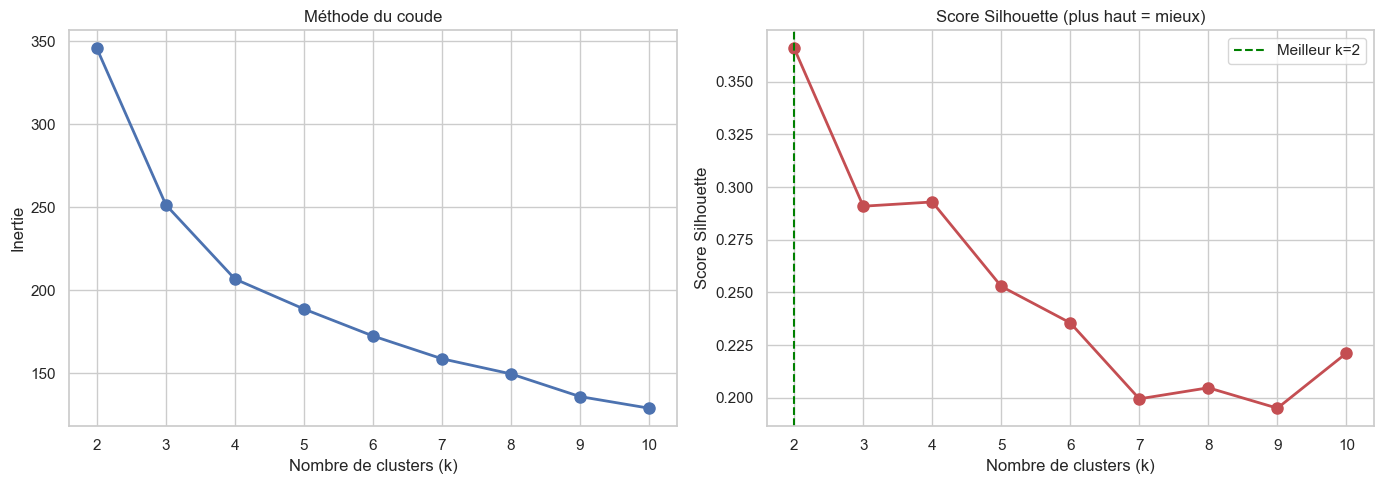

k optimal : 2


In [6]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f'  k={k} → inertie={km.inertia_:.0f}  silhouette={sil_scores[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')

axes[1].plot(list(K_range), sil_scores, 'ro-', linewidth=2, markersize=8)
best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Meilleur k={best_k}')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score Silhouette')
axes[1].set_title('Score Silhouette (plus haut = mieux)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '09_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'k optimal : {best_k}')

## 3. K-Means final

In [7]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_clust['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profiles = df_clust.groupby('cluster')[features_available].mean()
print('Profils moyens des clusters :')
print(cluster_profiles.round(2).to_string())

if 'happiness_score' in cluster_profiles.columns:
    LABELS = {}
    LABELS[int(cluster_profiles['happiness_score'].idxmax())] = 'Pays très attractifs'
    LABELS[int(cluster_profiles['happiness_score'].idxmin())] = 'Pays en difficulté'
    remaining = [c for c in range(K_FINAL) if c not in LABELS]
    inter = ['Pays émergents', 'Pays stables', 'Pays à fort potentiel']
    for i, c in enumerate(remaining):
        LABELS[c] = inter[i] if i < len(inter) else f'Groupe {c+1}'
else:
    LABELS = {i: f'Groupe {i+1}' for i in range(K_FINAL)}

df_clust['cluster_label'] = df_clust['cluster'].map(LABELS)
print(f'\nLabels des clusters :')
for c, label in LABELS.items():
    n = (df_clust['cluster'] == c).sum()
    print(f'  Cluster {c} → {label} ({n} pays)')

Profils moyens des clusters :
         gdp_per_capita  happiness_score  life_expectancy  freedom  corruption  social_support  inflation  gdp_growth
cluster                                                                                                              
0               9661.02             5.92              NaN     0.83        0.79            0.87        NaN        2.37
1              53148.48             6.97              NaN     0.88        0.45            0.93        NaN        1.70
2               4447.67             4.93              NaN     0.80        0.75            0.70        NaN        6.34
3               3621.27             4.35            62.94     0.64        0.81            0.69        2.3        2.27

Labels des clusters :
  Cluster 1 → Pays très attractifs (14 pays)
  Cluster 3 → Pays en difficulté (20 pays)
  Cluster 0 → Pays émergents (38 pays)
  Cluster 2 → Pays stables (16 pays)


## 4. Visualisation PCA 2D

Variance expliquée : PC1=53.2% | PC2=18.0%


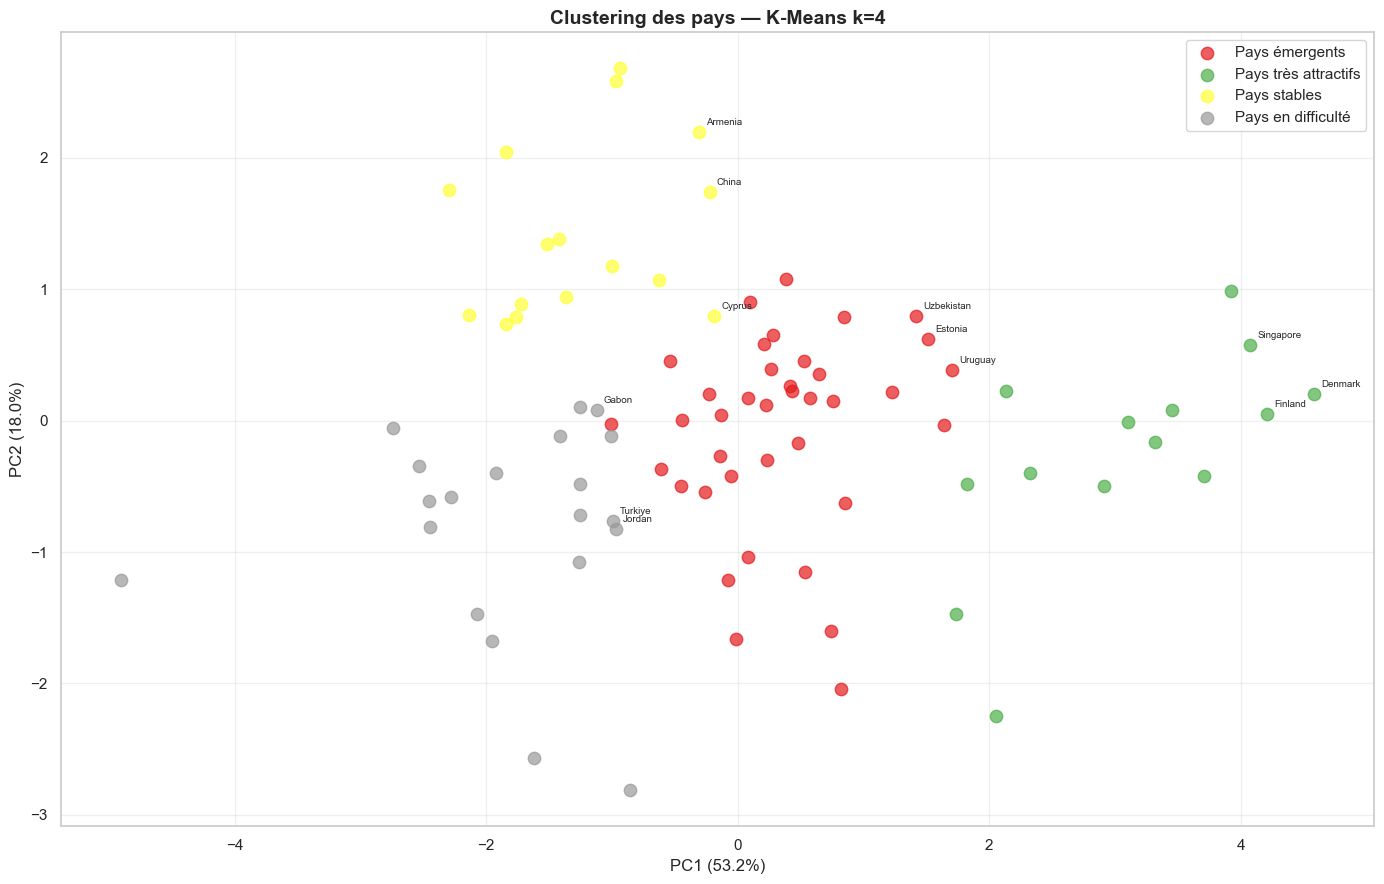

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_clust['pca_1'] = X_pca[:, 0]
df_clust['pca_2'] = X_pca[:, 1]

print(f'Variance expliquée : PC1={pca.explained_variance_ratio_[0]*100:.1f}% | PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.cm.Set1(np.linspace(0, 0.9, K_FINAL))

for cluster_id, color in zip(range(K_FINAL), colors):
    mask = df_clust['cluster'] == cluster_id
    grp = df_clust[mask]
    ax.scatter(grp['pca_1'], grp['pca_2'], c=[color], alpha=0.7,
               s=80, label=LABELS.get(cluster_id, f'Groupe {cluster_id+1}'))
    top = grp.nlargest(3, 'attractivity_score')['country_name'].tolist() if 'attractivity_score' in grp.columns else grp['country_name'].head(3).tolist()
    for _, row in grp[grp['country_name'].isin(top)].iterrows():
        ax.annotate(row['country_name'], (row['pca_1'], row['pca_2']),
                   textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Clustering des pays — K-Means k={K_FINAL}', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '10_clustering_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Liste des pays par cluster

In [9]:
for cluster_id in range(K_FINAL):
    label = LABELS.get(cluster_id, f'Cluster {cluster_id}')
    pays_cluster = df_clust[df_clust['cluster'] == cluster_id][['country_name', 'happiness_score', 'gdp_per_capita']]
    pays_cluster = pays_cluster.sort_values('happiness_score', ascending=False)
    print(f'\n{'─'*50}')
    print(f'  {label} ({len(pays_cluster)} pays)')
    print(f'{'─'*50}')
    print(pays_cluster.to_string(index=False))


──────────────────────────────────────────────────
  Pays émergents (38 pays)
──────────────────────────────────────────────────
          country_name  happiness_score  gdp_per_capita
               Bahrain            7.098    27259.743860
            Costa Rica            6.998    12884.685995
               Uruguay            6.600    18315.731698
           El Salvador            6.455     4320.116715
                Brazil            6.451     9029.833044
                 Italy            6.445    33812.788725
                Mexico            6.432    10369.555359
              Colombia            6.350     6472.545449
               Jamaica            6.309     6030.688964
            Kazakhstan            6.272     9457.126147
           Philippines            6.268     3400.789498
             Guatemala            6.262     4511.998396
                Serbia            6.241     7755.632986
            Uzbekistan            6.154     2041.384807
                Panama        

## 6. Export des résultats

In [10]:
df_cluster_result = df_clust[['country_code', 'year', 'cluster', 'cluster_label', 'pca_1', 'pca_2']]
df_with_cluster = df.merge(df_cluster_result, on=['country_code', 'year'], how='left')
df_with_cluster.to_csv(os.path.join(FINAL_DIR, 'master_with_clusters.csv'), index=False)

print('✅ master_with_clusters.csv sauvegardé !')
print(f'✅ {K_FINAL} groupes de pays identifiés')
print('\n→ Importe data/final/master_with_clusters.csv dans Power BI !')

✅ master_with_clusters.csv sauvegardé !
✅ 4 groupes de pays identifiés

→ Importe data/final/master_with_clusters.csv dans Power BI !
